<a href="https://colab.research.google.com/github/beyza-ozdemir/Analyse_Deaths/blob/main/analyse_death.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


deaths=pd.read_csv("Deaths_by_Police_US.csv",encoding="cp1252")
deaths.head()
deaths.info()
deaths.describe()
deaths.columns
deaths.nunique()

deaths.isnull().sum()
deaths.shape




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       2535 non-null   int64  
 1   name                     2535 non-null   object 
 2   date                     2535 non-null   object 
 3   manner_of_death          2535 non-null   object 
 4   armed                    2526 non-null   object 
 5   age                      2458 non-null   float64
 6   gender                   2535 non-null   object 
 7   race                     2340 non-null   object 
 8   city                     2535 non-null   object 
 9   state                    2535 non-null   object 
 10  signs_of_mental_illness  2535 non-null   bool   
 11  threat_level             2535 non-null   object 
 12  flee                     2470 non-null   object 
 13  body_camera              2535 non-null   bool   
dtypes: bool(2), float64(1), 

(2535, 14)

In [5]:
deaths["state"].value_counts()
deaths["gender"].value_counts()
deaths["race"].value_counts(dropna=False) #boş değerleride say
deaths["signs_of_mental_illness"].value_counts()
deaths["threat_level"].value_counts()
deaths["flee"].value_counts()
deaths["armed"].value_counts()
deaths["age"].value_counts()


,count
age,
25.0,103
36.0,91
31.0,85
29.0,83
24.0,83
...,...
80.0,1
14.0,1
13.0,1


In [72]:
deaths["date"]=pd.to_datetime(deaths["date"])
deaths["year"] = deaths["date"].dt.year
year_counts=deaths["year"].value_counts().sort_index()



year
2015    6106
2016    1986
2017    1604
Name: count, dtype: int64


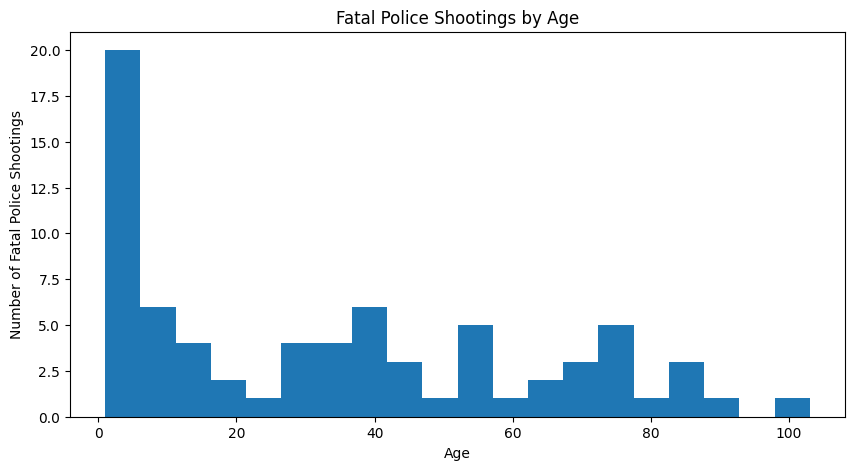

np.int64(77)

In [7]:
deaths["age"].value_counts().plot(kind="hist",bins=20,figsize=(10,5))
plt.xlabel("Age")
plt.ylabel("Number of Fatal Police Shootings")
plt.title("Fatal Police Shootings by Age")

plt.show()
deaths["age"].isna().sum() # eksik yaş kontrol ediyor


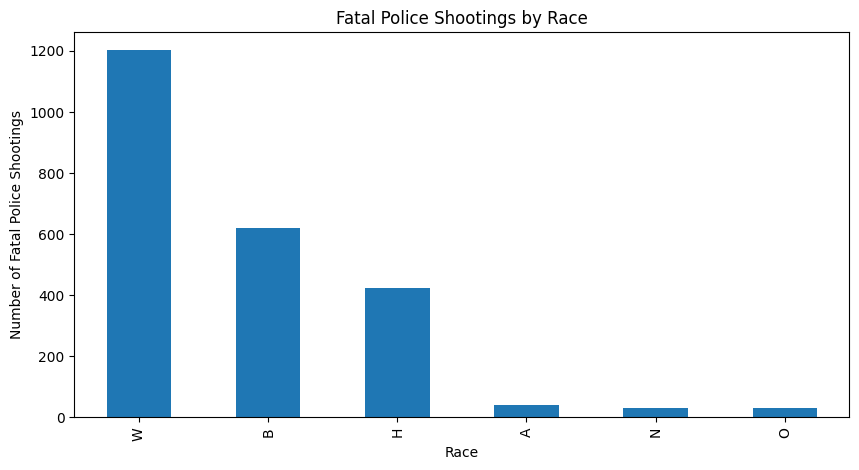

In [8]:
deaths["race"].value_counts().plot(kind="bar",figsize=(10,5))

plt.xlabel("Race")
plt.ylabel("Number of Fatal Police Shootings")
plt.title("Fatal Police Shootings by Race")

plt.show()

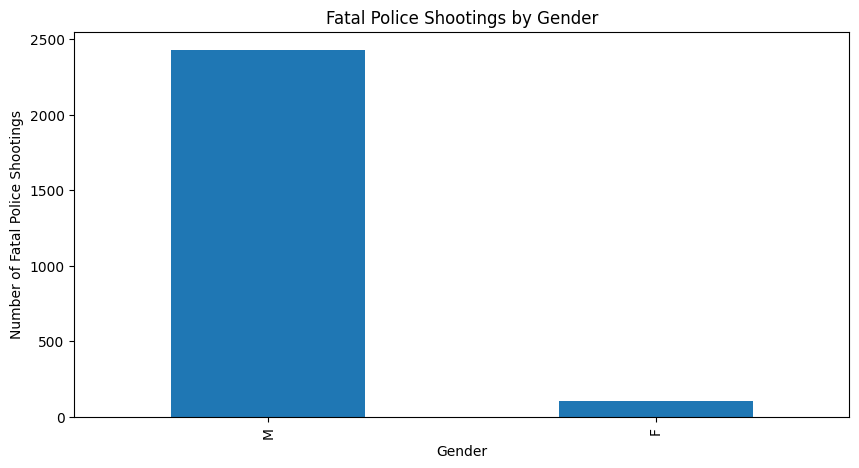

In [9]:
deaths["gender"].value_counts().plot(kind="bar",figsize=(10,5))

plt.xlabel("Gender")
plt.ylabel("Number of Fatal Police Shootings")
plt.title("Fatal Police Shootings by Gender")

plt.show()

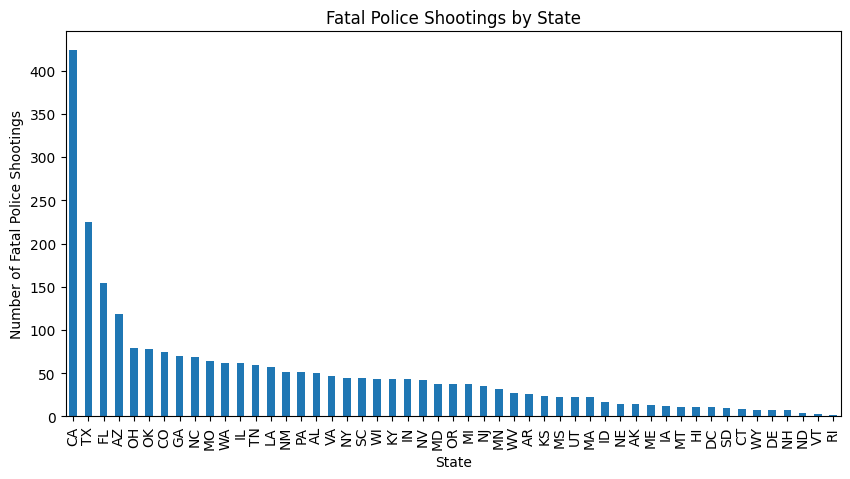

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       2535 non-null   int64         
 1   name                     2535 non-null   object        
 2   date                     2535 non-null   datetime64[ns]
 3   manner_of_death          2535 non-null   object        
 4   armed                    2526 non-null   object        
 5   age                      2458 non-null   float64       
 6   gender                   2535 non-null   object        
 7   race                     2340 non-null   object        
 8   city                     2535 non-null   object        
 9   state                    2535 non-null   object        
 10  signs_of_mental_illness  2535 non-null   bool          
 11  threat_level             2535 non-null   object        
 12  flee                     2470 non-

In [10]:
deaths["state"].value_counts().plot(kind="bar",figsize=(10,5))

plt.xlabel("State")
plt.ylabel("Number of Fatal Police Shootings")
plt.title("Fatal Police Shootings by State")

plt.show()
deaths.info()

In [26]:
income = pd.read_csv("Median_Household_Income_2015.csv",encoding="latin1")
income.head()
income.info()
income.columns
income["Median Income"] = pd.to_numeric(
    income["Median Income"],
    errors="coerce"
)

income["Median Income"].isna().sum()
income["Geographic Area"].unique()


income["City"] = income["City"].str.replace(
    r" city$| town$| CDP$",
    "",
    regex=True
)
income.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29322 entries, 0 to 29321
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Geographic Area  29322 non-null  object
 1   City             29322 non-null  object
 2   Median Income    29271 non-null  object
dtypes: object(3)
memory usage: 687.4+ KB


,Geographic Area,City,Median Income
0,AL,Abanda,11207.0
1,AL,Abbeville,25615.0
2,AL,Adamsville,42575.0
3,AL,Addison,37083.0
4,AL,Akron,21667.0
5,AL,Alabaster,71816.0
6,AL,Albertville,32911.0
7,AL,Alexander City,29874.0
8,AL,Alexandria,56058.0
9,AL,Aliceville,21131.0


In [37]:
deaths=deaths.rename(columns={"state":"Geographic Area",
                               "city": "City"})
deaths=deaths.merge(income,on=["Geographic Area","City"],how="left")
deaths.head()


,id,name,date,manner_of_death,armed,age,gender,race,City,Geographic Area,signs_of_mental_illness,threat_level,flee,body_camera,year,Median Income
0,3,Tim Elliot,2015-02-01,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False,2015,37072.0
1,4,Lewis Lee Lembke,2015-02-01,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False,2015,65765.0
2,5,John Paul Quintero,2015-03-01,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False,2015,45947.0
3,8,Matthew Hoffman,2015-04-01,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False,2015,81294.0
4,9,Michael Rodriguez,2015-04-01,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False,2015,47791.0


In [38]:
deaths[deaths["Median Income"].isna()].head()


,id,name,date,manner_of_death,armed,age,gender,race,City,Geographic Area,signs_of_mental_illness,threat_level,flee,body_camera,year,Median Income
9,17,Leslie Sapp III,2015-06-01,shot,toy weapon,47.0,M,B,Knoxville,PA,False,attack,Not fleeing,False,2015,NaN
15,29,Loren Simpson,2015-08-01,shot,vehicle,28.0,M,W,Huntley,MT,False,undetermined,Not fleeing,False,2015,NaN
27,50,Michael Goebel,2015-01-14,shot,vehicle,29.0,M,W,Franklin County,MO,False,attack,Not fleeing,False,2015,NaN
32,56,Donte Sowell,2015-01-15,shot,gun,27.0,M,B,Indianapolis,IN,False,attack,Foot,False,2015,NaN
36,64,Nathan Massey,2015-01-15,shot,gun,33.0,M,W,Evangeline Parish,LA,False,attack,Not fleeing,False,2015,NaN


In [47]:
poverty = pd.read_csv(
    "Pct_People_Below_Poverty_Level.csv",
    encoding="latin1"
)

poverty["City"] = poverty["City"].str.replace(
    r" city$| town$| CDP$",
    "",
    regex=True
)

deaths = deaths.merge(
    poverty,
    on=["Geographic Area", "City"],
    how="left"
)
deaths.head()

,id,name,date,manner_of_death,armed,age,gender,race,City,Geographic Area,signs_of_mental_illness,threat_level,flee,body_camera,year,Median Income,poverty_rate
0,3,Tim Elliot,2015-02-01,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False,2015,37072.0,28.6
1,4,Lewis Lee Lembke,2015-02-01,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False,2015,65765.0,14.9
2,5,John Paul Quintero,2015-03-01,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False,2015,45947.0,17.3
3,8,Matthew Hoffman,2015-04-01,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False,2015,81294.0,13.2
4,9,Michael Rodriguez,2015-04-01,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False,2015,47791.0,16.6


In [50]:
high_school = pd.read_csv(
    "Pct_Over_25_Completed_High_School.csv",
    encoding="latin1"
)

high_school["City"] = high_school["City"].str.replace(
    r" city$| town$| CDP$",
    "",
    regex=True
)
deaths = deaths.merge(
    high_school,
    on=["Geographic Area", "City"],
    how="left"
)
deaths.head()

,id,name,date,manner_of_death,armed,age,gender,race,City,Geographic Area,signs_of_mental_illness,threat_level,flee,body_camera,year,Median Income,poverty_rate,percent_completed_hs
0,3,Tim Elliot,2015-02-01,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False,2015,37072.0,28.6,80.1
1,4,Lewis Lee Lembke,2015-02-01,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False,2015,65765.0,14.9,88.1
2,5,John Paul Quintero,2015-03-01,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False,2015,45947.0,17.3,87.5
3,8,Matthew Hoffman,2015-04-01,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False,2015,81294.0,13.2,87
4,9,Michael Rodriguez,2015-04-01,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False,2015,47791.0,16.6,76.3


In [55]:
race = pd.read_csv(
    "Share_of_Race_By_City.csv",
    encoding="latin1"
)

race["City"] = race["City"].str.replace(
    r" city$| town$| CDP$",
    "",
    regex=True
)
race = race.rename(columns={
    "Geographic area": "Geographic Area"
})
deaths = deaths.merge(
    race,
    on=["Geographic Area", "City"],
    how="left"
)
deaths.head()


,id,name,date,manner_of_death,armed,age,gender,race,City,Geographic Area,...,body_camera,year,Median Income,poverty_rate,percent_completed_hs,share_white,share_black,share_native_american,share_asian,share_hispanic
0,3,Tim Elliot,2015-02-01,shot,gun,53.0,M,A,Shelton,WA,...,False,2015,37072.0,28.6,80.1,78.9,0.8,3.7,1.1,19.2
1,4,Lewis Lee Lembke,2015-02-01,shot,gun,47.0,M,W,Aloha,OR,...,False,2015,65765.0,14.9,88.1,70.9,2.6,1,8.9,21.1
2,5,John Paul Quintero,2015-03-01,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,...,False,2015,45947.0,17.3,87.5,71.9,11.5,1.2,4.8,15.3
3,8,Matthew Hoffman,2015-04-01,shot,toy weapon,32.0,M,W,San Francisco,CA,...,False,2015,81294.0,13.2,87,48.5,6.1,0.5,33.3,15.1
4,9,Michael Rodriguez,2015-04-01,shot,nail gun,39.0,M,H,Evans,CO,...,False,2015,47791.0,16.6,76.3,76.5,0.9,1.2,0.9,43.1


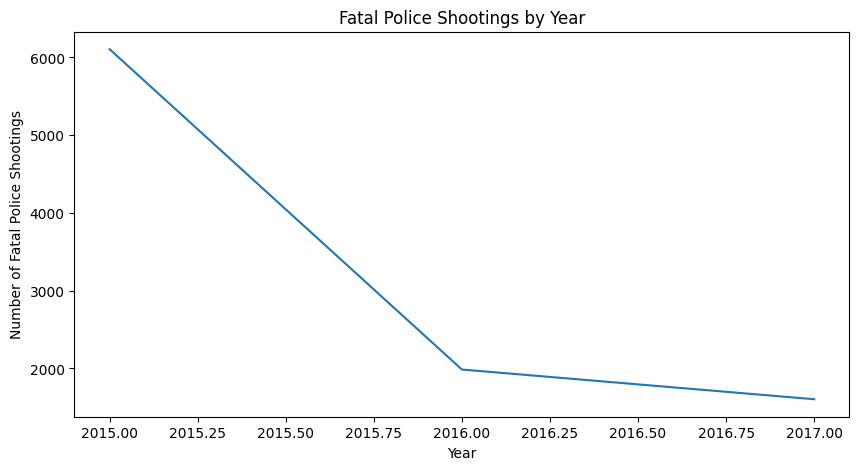

In [56]:
deaths["year"].value_counts().sort_index().plot(
    kind="line",
    figsize=(10,5)
)

plt.xlabel("Year")
plt.ylabel("Number of Fatal Police Shootings")
plt.title("Fatal Police Shootings by Year")

plt.show()

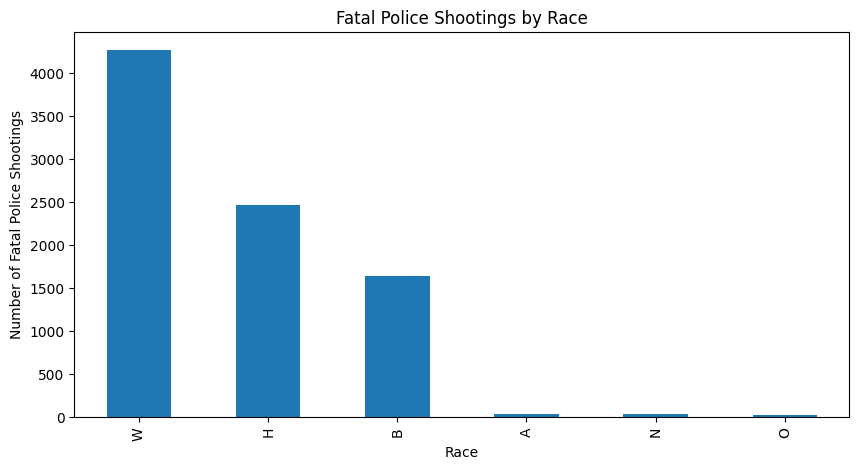

In [63]:
deaths["race"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.xlabel("Race")
plt.ylabel("Number of Fatal Police Shootings")
plt.title("Fatal Police Shootings by Race")

plt.show()

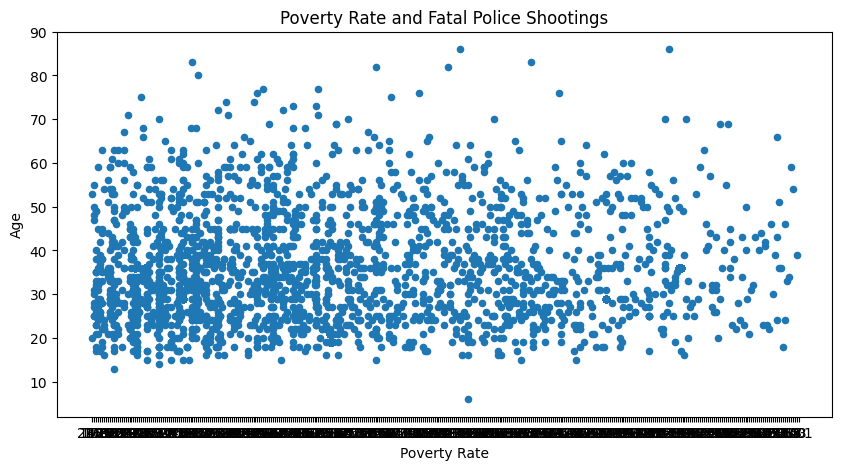

In [64]:
poverty_data = deaths.dropna(subset=["poverty_rate"])

poverty_data.plot(
    x="poverty_rate",
    y="age",
    kind="scatter",
    figsize=(10,5)
)

plt.xlabel("Poverty Rate")
plt.ylabel("Age")
plt.title("Poverty Rate and Fatal Police Shootings")

plt.show()

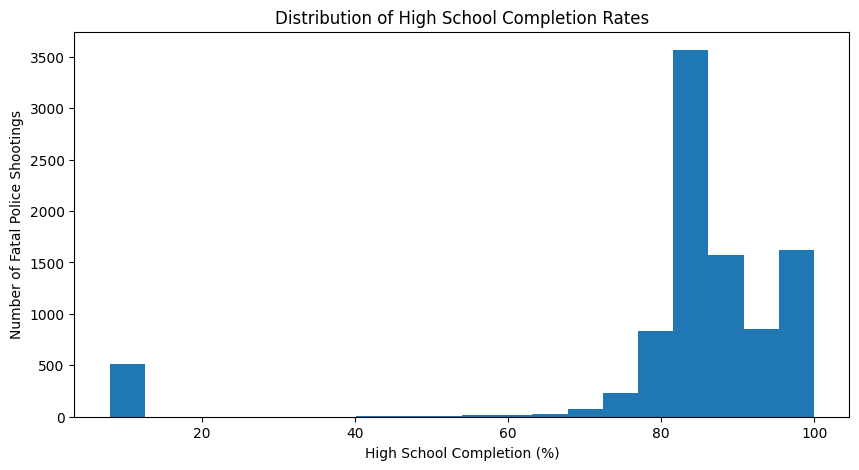

In [69]:
deaths["percent_completed_hs"].plot(
    kind="hist",
    figsize=(10,5),
    bins=20
)

plt.xlabel("High School Completion (%)")
plt.ylabel("Number of Fatal Police Shootings")
plt.title("Distribution of High School Completion Rates")

plt.show()

In [68]:
deaths["percent_completed_hs"] = pd.to_numeric(
    deaths["percent_completed_hs"],
    errors="coerce"
)
plt.show()

In [58]:
city_data = deaths.groupby(
    ["Geographic Area", "City"]
).agg(
    shooting_count=("id", "count"),
    median_income=("Median Income", "first"),
    poverty_rate=("poverty_rate", "first"),
    high_school=("percent_completed_hs", "first")
).reset_index()
city_data.head()

,Geographic Area,City,shooting_count,median_income,poverty_rate,high_school
0,AK,Anchorage,3,NaN,None,None
1,AK,Barrow,1,76902.0,11.7,84.6
2,AK,Big Lake,1,70988.0,9.6,90.4
3,AK,Fairbanks,5,55229.0,13.1,91.2
4,AK,Houston,1,50438.0,14.8,90.2
